In [1]:
!pip install -q scikit-image cifar10-web numpy matplotlib tqdm

In [2]:
from cifar10_web import cifar10
import numpy as np
import random
import matplotlib.pyplot as plt

from tqdm import tqdm

from skimage import color

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
train_images, train_labels, test_images, test_labels = cifar10(path="/tmp/cifar10")


In [4]:
Xtest = test_images.reshape(-1,3,32,32).transpose(0,2,3,1)
Xtrain = train_images.reshape(-1,3,32,32).transpose(0,2,3,1)

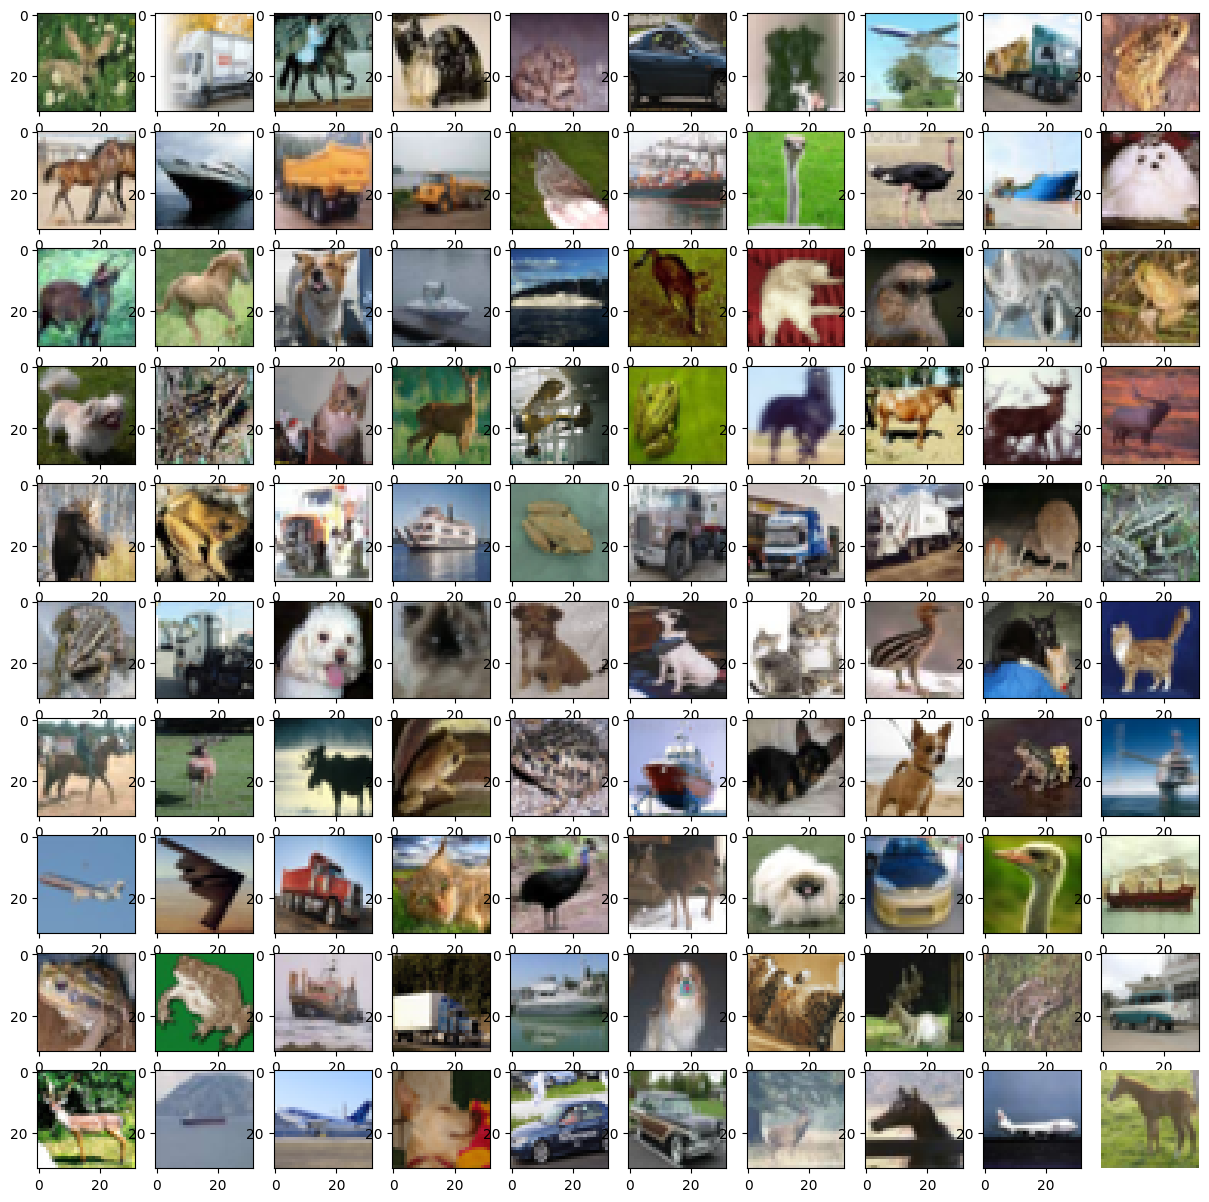

In [5]:
randomaXtrainIDX = [random.randint(0,Xtrain.shape[0]) for _ in range(100)]

plt.figure(figsize=(15,15))

for i,idx in enumerate(randomaXtrainIDX):
    plt.subplot(10,10,i+1)
    plt.imshow(Xtrain[idx])

plt.axis("off")
plt.show()

In [6]:
Xtrain_LAB = color.rgb2lab(Xtrain, channel_axis=-1)
Xtrain_L = torch.tensor(Xtrain_LAB[:,:,:,0], dtype=torch.float)
Xtrain_L = Xtrain_L.reshape(*Xtrain_L.shape, 1).permute(0,3,1,2).to(device)/100 - 0.5
Xtrain_AB = torch.tensor(Xtrain_LAB[:,:,:,1:].transpose(0,3,1,2), dtype=torch.float).to(device)/100


Xtest_LAB = color.rgb2lab(Xtest, channel_axis=-1)
Xtest_L = torch.tensor(Xtest_LAB[:,:,:,0], dtype=torch.float)
Xtest_L = Xtest_L.reshape(*Xtest_L.shape, 1).permute(0,3,1,2).to(device)/100 - 0.5
Xtest_AB = torch.tensor(Xtest_LAB[:,:,:,1:].transpose(0,3,1,2), dtype=torch.float).to(device)/100


Xtrain_L.min(),Xtrain_L.max(), Xtrain_AB.min(), Xtrain_AB.max()

(tensor(-0.5000, device='cuda:0'),
 tensor(0.5000, device='cuda:0'),
 tensor(-1.0786, device='cuda:0'),
 tensor(0.9823, device='cuda:0'))

In [7]:
model = nn.Sequential(
    # Encoder
    nn.Conv2d(in_channels=1, out_channels=128, kernel_size=3, padding='same'),
    nn.ReLU(),
    
    nn.Conv2d(128,128, kernel_size=3, padding="same"),
    nn.ReLU(),
    
    nn.Conv2d(128,128, kernel_size=3, padding="same"),
    nn.ReLU(),
    
    nn.Conv2d(128,128, kernel_size=3, padding="same"),
    nn.ReLU(),

    nn.Conv2d(128,128, kernel_size=3, padding="same"),
    nn.ReLU(),

    # Decoder
    nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.ConvTranspose2d(in_channels=128, out_channels=2, kernel_size=3, padding=1),
    # nn.Tanh(),
).to(device)

model = torch.compile(model, mode="reduce-overhead") 

In [8]:
model(Xtrain_L[:100]).shape == Xtrain_AB[:100].shape

True

In [9]:

# Wrap into a Dataset
train_ds = TensorDataset(Xtrain_L, Xtrain_AB)



In [10]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, amsgrad=True)


model.train()

epochs = 20
pbar = tqdm(range(epochs), colour='blue', leave=True, ncols=100)
for epoch in pbar:
    # Create a DataLoader
    train_loader = DataLoader(train_ds, batch_size=500, shuffle=True)

    for xb, yb in train_loader:
        preds = model(xb)
        loss = loss_fn(preds, yb)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        pbar.set_postfix_str(f"loss:{float(loss)*100:.3f}%")

100%|██████████████████████████████████████████████████| 20/20 [13:10<00:00, 39.54s/it, loss:1.447%]


In [11]:
# ## TRAIN WTH SPLUS
# # https://github.com/kvfrans/splus

# from splus import SPlus

# loss_fn = nn.MSELoss()
# optimizer = SPlus(model.parameters(), lr=1e-3*100*2)

# optimizer.train() # New in SPlus: Include this!
# model.train()

# epochs = 5
# pbar = tqdm(range(epochs), colour='blue', leave=True, ncols=100)
# for epoch in pbar:
#     # Create a DataLoader
#     train_loader = DataLoader(train_ds, batch_size=1000, shuffle=True)

#     for xb, yb in train_loader:
#         preds = model(xb)
#         loss = loss_fn(preds, yb)
    
#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()
        
#         # Eval step
#         optimizer.eval() # New in SPlus: Include this!
    
#         pbar.set_postfix_str(f"loss:{float(loss)*100:.3f}%")

In [12]:
random10 = [random.randint(0,Xtest_L.shape[0]) for i in range(10)]

original = Xtest[random10]
l = Xtest_L[random10]
ab = model(l)

In [13]:
l.max()

tensor(0.5000, device='cuda:0')

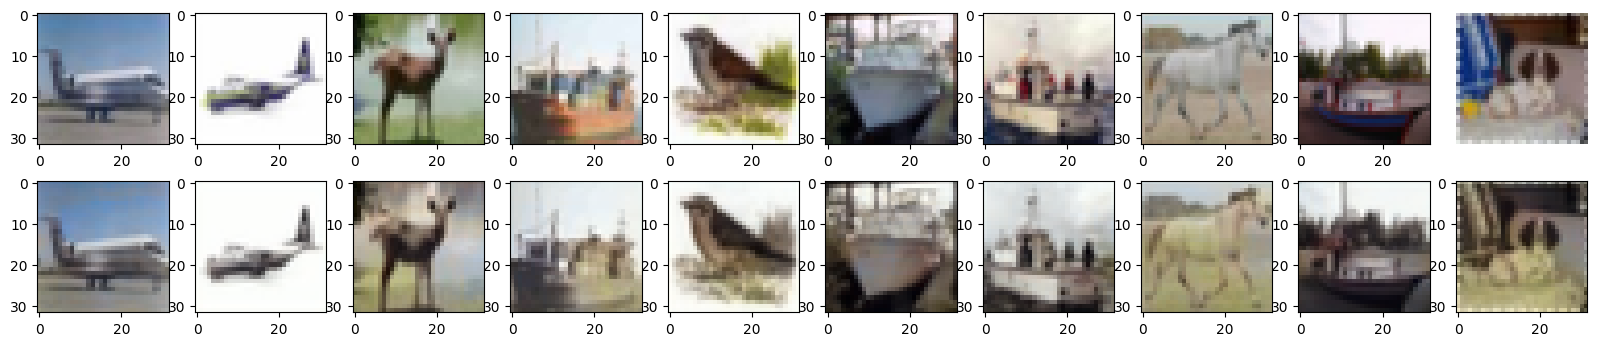

In [14]:
plt.figure(figsize=(20,4))

for idx in range(10):
    img = np.zeros((32,32,3))
    img[:,:,0] = (l[idx].cpu().detach().numpy() + 0.5)*100
    img[:,:,1:] = ab[idx].cpu().detach().numpy().transpose(1,2,0)*128
    
    plt.subplot(2,10,11+idx)
    plt.imshow(color.lab2rgb(img))
    
    
    plt.subplot(2,10,1+idx)
    plt.imshow(original[idx])


plt.axis("off")
plt.show()

In [15]:
Xtrain_L.max()

tensor(0.5000, device='cuda:0')